# Probabilistic Power Spectral Density Plots

A tutorial by Simon Ramirez

This notebook details the process of creating PPSD plots.

## 0. Imports

In [ ]:
# For Configuration File
import yaml
from pathlib import Path
import importlib

config_path = ### Input the path to your config file ###
with open(config_path, "r") as f:
    config = yaml.safe_load(f)


name = config["name"]
seismic_path = config["seismic_data_path"]
seismic_data = Path(config['seismic_data_path'])
align_module = config['align_module']
process_module = config['process_module']


# obspy GitHub:
# https://github.com/obspy/obspy
from obspy import UTCDateTime as UTC

# seismic-data-quality GitHub: 
# https://github.com/Ramirezs873/seismic-data-quality
spec1 = importlib.util.spec_from_file_location("process", process_module)
process = importlib.util.module_from_spec(spec1)
spec1.loader.exec_module(process)

# seismic-sensor-anlysis GitHub:
# https://github.com/Ramirezs873/seismic-sensor-analysis
spec2 = importlib.util.spec_from_file_location("align", align_module)
align = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(align)



## 1. Gather Seismic Data



To gather seismic data, a premade function from a supplementary Library (align.py - seismic-sensor-analysis) is used.

seismic_data() retrieves seismic data from a sensor for the given specifications and saves it as an mseed file. If The data has previously been stored locally, then the function instead opens the file.

In [28]:
wave_dict = align.seismic_data(client1 = 'AUSPASS', 
                         network1 = 'Z9', 
                         station1 = 'CWA81',
                         location1 = "*", 
                         channel1 = "*",
                         t_start = UTC(2022, 12, 25, 0, 0,0),
                         t_end = UTC(2023, 1, 1, 0, 0, 0),
                         user1='Z9', password1='peach25',
                         config = config)

Reading existing file: C:\Users\simon\Desktop\UTAS\2026 Sem 1\KAA308 CWA Appraisal Research\GitHub\seismic-data-quality\Seismic Files\station_data_Z9_5stations_2022-12-25.mseed


## 2. Gather Station Information

To create a PPSD we need to gather the station information as well. 

event_catalogue() has multiple purposes. It can be used to lookup and catalogue event information for specific sensors but it can also be used to create an ObsPy inventory. 

The first ([0]) output of the function is event information and the second ([1]) is the inventory. For PPSDs, we need the second output.

These outputs can be saved as a csv and xml file respectively. If these files are saved locally, then the function reads those files instead.

When calling the function, ensure the event time lines up with the seismic data time in part 1.

In [24]:
catalog = process.event_catalogue(client ="AUSPASS", 
                                  network = 'Z9', 
                                  station = 'CWA81', 
                                  event_t0 = UTC(2022, 12, 25, 0, 0,0),
                                  event_t1 = UTC(2023, 1, 1, 0, 0, 0),
                                  user='Z9', password='peach25',
                                  title = "CWA81_Info",
                                  config = config,
                                  csv = False,
                                  map = False)

File not found. Downloading data
Saved to: C:\Users\simon\Desktop\UTAS\2026 Sem 1\KAA308 CWA Appraisal Research\GitHub\seismic-data-quality\Seismic Files\station_data_CWA.xml


## 3. Create PPSD Plot

Now the outputs of part 1. and 2. can be used to create PPSD plots. 

ppsd() from process.py is based on the ObsPy function PPSD(). The process is now much simpler.

There is the option to select which seismic channels to plot and the option to save the plot as a png file. the max_percentage option assists with visualising the most common frequencies.

Processing Z9.CWA81....
Plotting PPSD for Z9.CWA81. EW component...


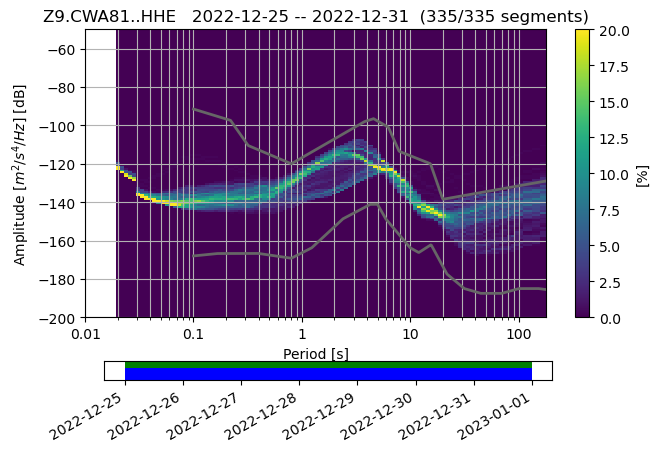

Plotting PPSD for Z9.CWA81. NS component...


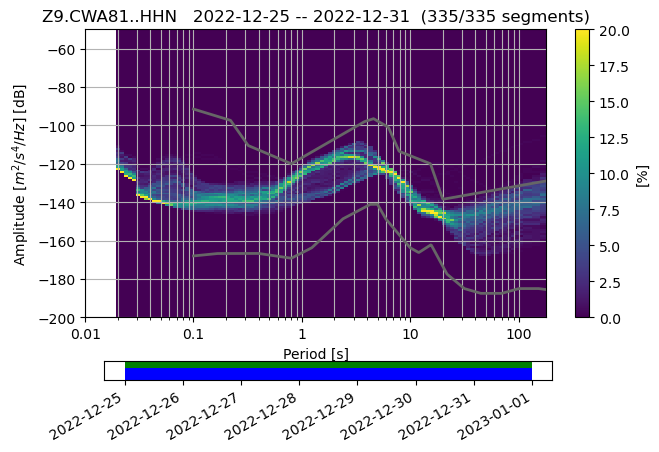

Plotting PPSD for Z9.CWA81. Z component...


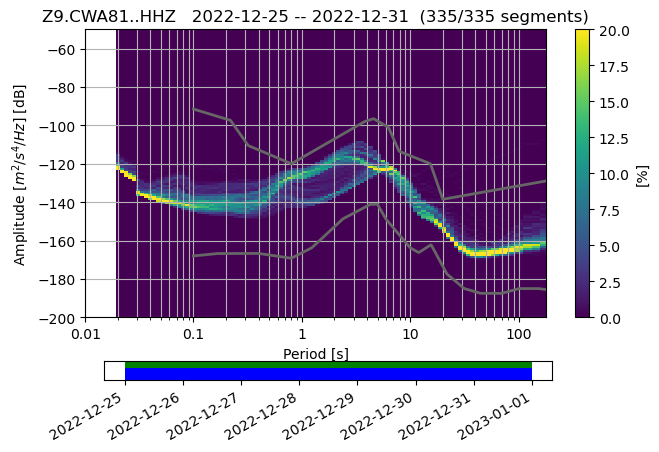

In [30]:
process.ppsd(wave_dict = wave_dict,
             metadata = catalog[1],
             max_percentage = 20,
             plot_channel = ['EW', 'NS', 'Z'],
             save_png = False,
             png_title = "CWA81_PPSD",
             show_plot = True)
